# Comparing four models on one patch

**Dr. Panagiotis Sakagiannis, Dr. Alexandros Marantis**

## About this notebook

Every assay so far ran one kind of animal. This one runs **four at once, in the same arena**, and
the four differ in exactly two things : whether they can smell, and whether they can eat.

All eighty larvae are released at the centre of the arena, **on top of a single odorous food patch**
two centimetres across. Nobody has to find it - everybody starts on it. What the assay asks is which
of them is still getting something out of it ten minutes later. Feeding is what an animal can do
while it is on the patch; smelling is what could bring it back once it has wandered off. Crossing
the two gives a 2x2 design :

| group | smells | eats | what happens to it |
|---|---|---|---|
| `explorer` | no | no | wanders off, and that is all |
| `navigator` | **yes** | no | stays at the patch, with nothing to gain there |
| `Orco` | no | **yes** | eats, but only while chance keeps it on the patch |
| `forager` | **yes** | **yes** | stays *and* eats, and gets more than either alone |

The group names are the point, and they are more informative than the model IDs behind them.
**`Orco`** is the olfactory co-receptor of *Drosophila* : an Orco mutant has an intact feeding
apparatus and no functioning sense of smell, which is exactly the third row of the table. The models
implementing the four groups are `explorer`, `navigator`, `max_feeder` and `max_forager`. None of
them has any energetics - nothing metabolises what is eaten - and apart from the two modules under
test they are the same animal : same body, same crawler, same turner, same intermittency.

**What you will be able to do afterwards**

- Run several larva groups side by side in one experiment and compare them.
- Say which behavioral module is responsible for which part of a foraging result.
- Read a comparison across groups in the figures the analysis produces.
- Check that the models you are comparing really do differ only in what you think they differ in.

**Prerequisites** : [Chemotaxis](chemotaxis.ipynb) for the olfactor and
[Feeding](feeding.ipynb) for the feeder. This notebook puts the two together.

**Cost** : four groups of 20 larvae for 10 simulated minutes, which is eighty animals and by some
way the most expensive experiment of the section - about forty minutes of compute, most of it in the
per-group enrichment that follows the run.

**Switches in this notebook**

| switch | default | what it turns on |
|---|---|---|
| `RUN_SIMULATION` | `True` | the experiment itself, and therefore every figure below |
| `SAVE_VIDEO` | `False` | a second, rendered run that writes a video of all four groups |

## Setup

In [1]:
%matplotlib inline

import pandas as pd

import larvaworld
from larvaworld.lib import reg
from larvaworld.lib.sim.single_run import ExpRun

larvaworld.VERBOSE = 1

# Tutorial safety switches
RUN_SIMULATION = True  # the point of this notebook; ~40 minutes of compute
SAVE_VIDEO = False  # a second, rendered run that writes a video

EXPERIMENT = "single_odor_patch_x4"
N = 20  # larvae per group; the stored experiment's duration and timestep are left untouched

MEDIA_DIR = "./media/simulated_experiments"
plot_dir = f"{MEDIA_DIR}/{EXPERIMENT}"

Initializing larvaworld registry


Registry configured!


## Section 1 : The experiment

One odorous food patch at the centre of a 100 mm arena, and four larva groups released exactly on
it. The patch is two centimetres across in an arena five times that, so leaving it is easy and
coming back is not.

In [2]:
conf = reg.conf.Exp.getID(EXPERIMENT)
env = conf.env_params

print(f"Experiment : {EXPERIMENT}")
print(f"  duration : {conf.duration} min   timestep : {conf.dt} s")
print(
    f"  arena    : {env.arena.geometry}, {[round(x * 1000) for x in env.arena.dims]} mm"
)
print(f"  odorscape: {env.odorscape.odorscape}")
for sid, s in env.food_params.source_units.items():
    print(
        f"  patch {sid!r} at {[round(v * 1000) for v in s.pos]} mm : "
        f"radius {round(s.radius * 1000)} mm, food {s.amount}, "
        f"odor {s.odor.id!r} (intensity {s.odor.intensity})"
    )

Experiment : single_odor_patch_x4
  duration : 10.0 min   timestep : 0.1 s
  arena    : rectangular, [100, 100] mm
  odorscape: Gaussian
  patch 'Patch' at [0, 0] mm : radius 10 mm, food 0.1, odor 'Odor' (intensity 2.0)


The four groups, and the capability table read straight out of their models rather than asserted.
An olfactor module means the animal can smell; a feeder module means it can eat.

In [3]:
rows = []
for gid, g in conf.larva_groups.items():
    m = reg.conf.Model.getID(g.model)
    b = m.brain
    rows.append(
        {
            "group": gid,
            "model": g.model,
            "smells": b.olfactor is not None,
            "olfactor wiring": (
                "-"
                if b.olfactor is None
                else (
                    "stop-on-decrease"
                    if b.olfactor.brute_force
                    else "steers the turner"
                )
            ),
            "eats": b.feeder is not None,
            "EEB": b.intermitter.EEB,
            "energetics": m.energetics,
            "colour": g.color,
        }
    )
display(pd.DataFrame(rows).set_index("group"))

,model,smells,olfactor wiring,eats,EEB,energetics,colour
group,,,,,,,
forager,max_forager,True,steers the turner,True,0.9,None,green
Orco,max_feeder,False,-,True,0.9,None,red
navigator,navigator,True,steers the turner,False,0.0,None,blue
explorer,explorer,False,-,False,0.0,None,purple


Two of those columns are worth reading before the results.

The **`EEB`** is the exploration-exploitation balance of the intermittency module : 0 for the two
groups that cannot eat, because there is nothing to exploit, and 0.9 for the two that can. It is the
one asymmetry this design cannot remove - a feeder that never chooses to feed is not a feeder.

The **olfactor wiring** says how the sensor reaches locomotion, and what matters is that it reads the
same for both groups that have one : the olfactory signal modulates the **turner**, so the animal
steers up the gradient. The module has a second setting, `brute_force`, in which that steering output
is suppressed and the sensor instead interrupts locomotion when the concentration falls - a different
behavior entirely, and one that would make the two olfactory groups incomparable. `navigator` and
`max_forager` carry the identical olfactor : same sensor, same gain of 150, same coupling. That is
what makes the difference between them a difference of the feeder alone.

## Section 2 : Running it

One call produces four datasets, one per group. They share the arena, the clock and the patch, so
anything that differs between them comes from the models.

In [4]:
r = ExpRun(experiment=EXPERIMENT, N=N)

print(
    f"{EXPERIMENT!r} : {r.p.duration} min at dt={r.p.dt} s  ->  {r.p.Nsteps} timesteps"
)
for gid, g in r.p.larva_groups.items():
    print(f"  {gid:10s} {g.distribution.N} larvae")

'single_odor_patch_x4' : 10.0 min at dt=0.1 s  ->  6000 timesteps
  forager    20 larvae
  Orco       20 larvae
  navigator  20 larvae
  explorer   20 larvae


In [5]:
ds = []
if RUN_SIMULATION:
    r.simulate()
    ds = r.datasets
    print("Datasets :", [d.id for d in ds])
else:
    print("Set RUN_SIMULATION = True to run the experiment.")

--- Simulation single_odor_patch_x4_18 initialized!--- 
--- Simulation single_odor_patch_x4_18 : Generating agent groups!--- 



Run time: 0:11:08.978337
Simulation finished


--- Simulation single_odor_patch_x4_18 completed in 670 seconds!--- 
--- Enriching dataset forager ---
Vector orientations are already computed. If you want to recompute them, set recompute to True


Angular analysis complete.


Spatial analysis complete.


...

***** Dataset forager stored.-----


***** Dataset Orco stored.-----


***** Dataset navigator stored.-----


***** Dataset explorer stored.-----
Simulation single_odor_patch_x4_18 stored in directory C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SimGroup/exp_runs/single_odor_patch_x4/single_odor_patch_x4_18


Datasets : ['forager', 'Orco', 'navigator', 'explorer']


## Section 3 : What each group did

Before any figure, the numbers that summarize the assay : how much each group ate, how many feeding
motions it made, how much of the experiment it spent on the patch, and how far it travelled.

One column needs care. The platform's `on_food_dur_ratio` is a **feeder state**, not a position : it
is recorded from the feeding machinery, so it stays empty for the two groups that have no feeder
even when they are standing on the patch. Occupancy is therefore also measured spatially, straight
from the distance to the source that every dataset records, and the two columns are kept apart.

In [6]:
# The food patch is one of the experiment's sources, and every source-related
# column and figure is named after it, so read the name rather than assume it.
SOURCE = list(r.p.source_xy)[0] if ds else None
PATCH_RADIUS = list(conf.env_params.food_params.source_units.values())[0].radius
if ds:
    print(
        f"Source : {SOURCE!r} at {r.p.source_xy[SOURCE]}, radius {PATCH_RADIUS * 1000:.0f} mm"
    )

Source : 'Object' at (0.0, 0.0), radius 10 mm


In [7]:
summary = None
if ds:
    end_cols = {
        "amount_eaten": "eaten",
        "num_feeds": "feed motions",
        "on_food_dur_ratio": "on food (feeder state)",
        "cum_dst": "path length (m)",
    }
    rows = {}
    for d in ds:
        row = {
            lab: (round(float(d.e[c].mean()), 5) if c in d.e.columns else float("nan"))
            for c, lab in end_cols.items()
        }
        dst = d.s[f"dst_to_{SOURCE}"]
        row["on patch (position)"] = round(float((dst < PATCH_RADIUS).mean()), 4)
        row["median distance (mm)"] = round(float(dst.median() * 1000), 1)
        rows[d.id] = row
    summary = pd.DataFrame(rows).T[
        [
            "eaten",
            "feed motions",
            "on food (feeder state)",
            "on patch (position)",
            "median distance (mm)",
            "path length (m)",
        ]
    ]
    summary.index.name = "group"
    display(summary)

,eaten,feed motions,on food (feeder state),on patch (position),median distance (mm),path length (m)
group,,,,,,
forager,0.00766,71.25,0.0545,0.1768,22.7,0.77442
Orco,0.00553,46.80,0.0377,0.0797,38.2,0.78378
navigator,0.00000,0.00,0.0000,0.1458,22.9,0.81849
explorer,0.00000,0.00,0.0000,0.0444,38.5,0.79756


Read the table by pairs. The design pays off : each capability shows up in a different column.

**Olfaction decides where an animal is.** Look at the median distance to the patch. The two groups
that can smell sit at almost exactly the same distance as each other, and so do the two that cannot,
with a wide gap between the pairs. Whether an animal can eat barely moves this number; whether it can
smell accounts for all of it. That is about as clean a main effect as a simulation gives you, and it
is [Chemotaxis](chemotaxis.ipynb) measured against a food patch instead of a bare odor source.

**Feeding decides what it gets out of being there.** Only the two groups with a feeder eat anything
at all, and that half of the result is all-or-nothing : no feeder, no food, however long the animal
stands on the patch.

**The two together are worth more than either alone.** `forager` occupies the patch roughly twice as
often as the anosmic `Orco`, and turns that into more food and more feeding motions. But the gain is
not the olfactor's alone : `navigator` smells exactly as well and occupies the patch *less* than
`forager` does, at the same distance from it. A navigator that reaches the patch keeps crawling
across it; a forager that reaches it stops and feeds. Smelling brings the animal to the food, and
feeding is what keeps it there.

**Path length barely moves.** All four groups travel within a few percent of the same distance. At
this patch size and this exploration-exploitation balance nobody trades locomotion for feeding : the
groups differ in *where* they are, not in how much they move.

The same comparison as a distance to the patch over time. Every dataset records how far each animal
is from the source at every timestep, which measures occupancy directly and works for all four
groups, feeder or not.

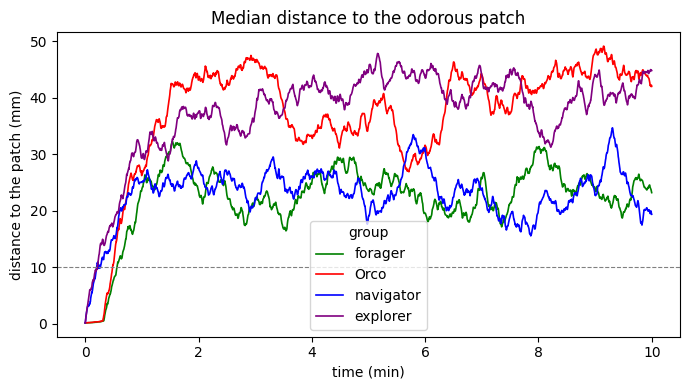

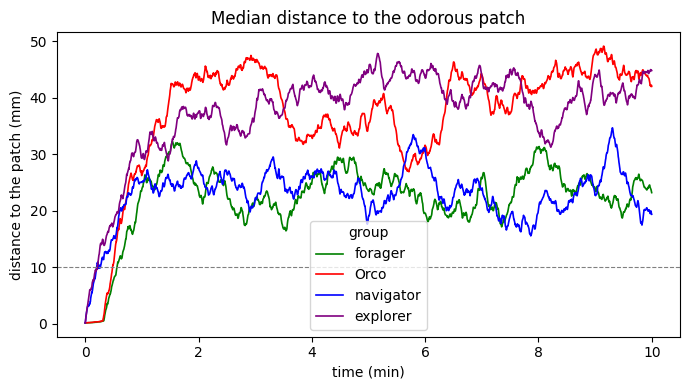

In [8]:
if ds:
    dst_col = f"dst_to_{SOURCE}"
    dist = pd.DataFrame(
        {
            d.id: d.s[dst_col].groupby(level="Step").median() * 1000
            for d in ds
            if dst_col in d.s.columns
        }
    )
    dist.index = dist.index * r.p.dt / 60
    ax = dist.plot(
        figsize=(7, 4),
        color=[d.config.color for d in ds],
        linewidth=1.2,
    )
    ax.axhline(PATCH_RADIUS * 1000, color="grey", linestyle="--", linewidth=0.8)
    ax.set_xlabel("time (min)")
    ax.set_ylabel("distance to the patch (mm)")
    ax.set_title("Median distance to the odorous patch")
    ax.legend(title="group")
    ax.figure.tight_layout()
    display(ax.figure)

All four curves start at zero, because all four groups start on the patch; the dashed line is the
patch edge. They separate into two pairs almost immediately - and the pairs are the olfactory one and
the anosmic one, not the feeding one. The anosmic groups leave and keep going, settling at the
distance a random walk in a 100 mm arena produces. The olfactory groups level off far lower, whether
or not they have anything to eat there.

## Section 4 : The analysis

Every stored experiment knows which figures belong to it. `ExpRun.analyze()` looks the experiment up,
runs the plots registered for that kind of assay, writes them next to the datasets, and returns them
grouped by topic in `r.figs`. Nothing has to be chosen by hand.

In [9]:
if RUN_SIMULATION:
    r.analyze()
    print("Figure groups produced :")
    for gname, group in r.figs.items():
        print(f"  {gname:12s} {list(group)}")
    print()
    print(f"All of them were also written to {r.plot_dir}")

Plot comparative_trajectories_default.pdf saved as C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SimGroup/exp_runs/single_odor_patch_x4/single_odor_patch_x4_18/plots/traj\comparative_trajectories_default.pdf


Plot aligned2origin.pdf saved as C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SimGroup/exp_runs/single_odor_patch_x4/single_odor_patch_x4_18/plots/traj\aligned2origin.pdf


Plot runsNpauses.pdf saved as C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SimGroup/exp_runs/single_odor_patch_x4/single_odor_patch_x4_18/plots/general\runsNpauses.pdf


Plot Y position.pdf saved as C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SimGroup/exp_runs/single_odor_patch_x4/single_odor_patch_x4_18/plots/patch\Y position.pdf


Plot nav_index.pdf saved as C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SimGroup/exp_runs/single_odor_patch_x4/single_odor_patch_x4_18/plots/patch\nav_index.pdf


Plot turn_amplitude.pdf saved as C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SimGroup/exp_runs/single_odor_patch_x4/single_odor_patch_x4_18/plots/patch\turn_amplitude.pdf


Plot bearing_to_Object.pdf saved as C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SimGroup/exp_runs/single_odor_patch_x4/single_odor_patch_x4_18/plots/locomotion_relative_to_source_Object\bearing_to_Object.pdf


Plot dst_to_Object.pdf saved as C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SimGroup/exp_runs/single_odor_patch_x4/single_odor_patch_x4_18/plots/locomotion_relative_to_source_Object\dst_to_Object.pdf


Plot scaled_dst_to_Object.pdf saved as C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SimGroup/exp_runs/single_odor_patch_x4/single_odor_patch_x4_18/plots/locomotion_relative_to_source_Object\scaled_dst_to_Object.pdf
Figure groups produced :
  traj         ['trajectories', 'aligned2origin']
  general      ['epochs']
  patch        ['Y position', 'navigation index', 'turn amplitude']
  locomotion_relative_to_source_Object ['bearing_to_Object', 'dst_to_Object', 'scaled_dst_to_Object']

All of them were also written to C:\Users\Panos\larvaworld_GH_nawrotlab\larvaworld\src\larvaworld/data/SimGroup/exp_runs/single_odor_patch_x4/single_odor_patch_x4_18/plots


`r.figs` holds the figure objects themselves, so they can be shown here one group at a time.

In [10]:
def show(group):
    """Display every figure of one analysis group."""
    if not RUN_SIMULATION or group not in r.figs:
        return
    for name, fig in r.figs[group].items():
        print(name)
        display(fig)

### The paths

All four groups in the same arena, each in its own colour. The difference between a track that
converges on the centre and one that ignores it is visible without any statistic.

trajectories


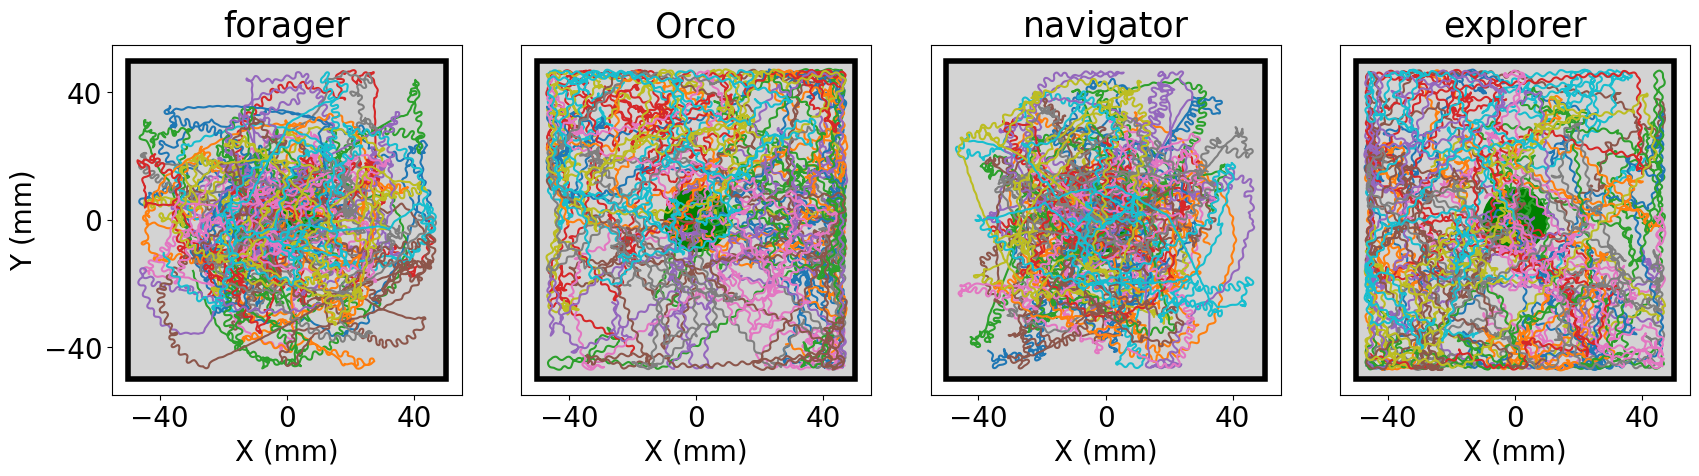

aligned2origin


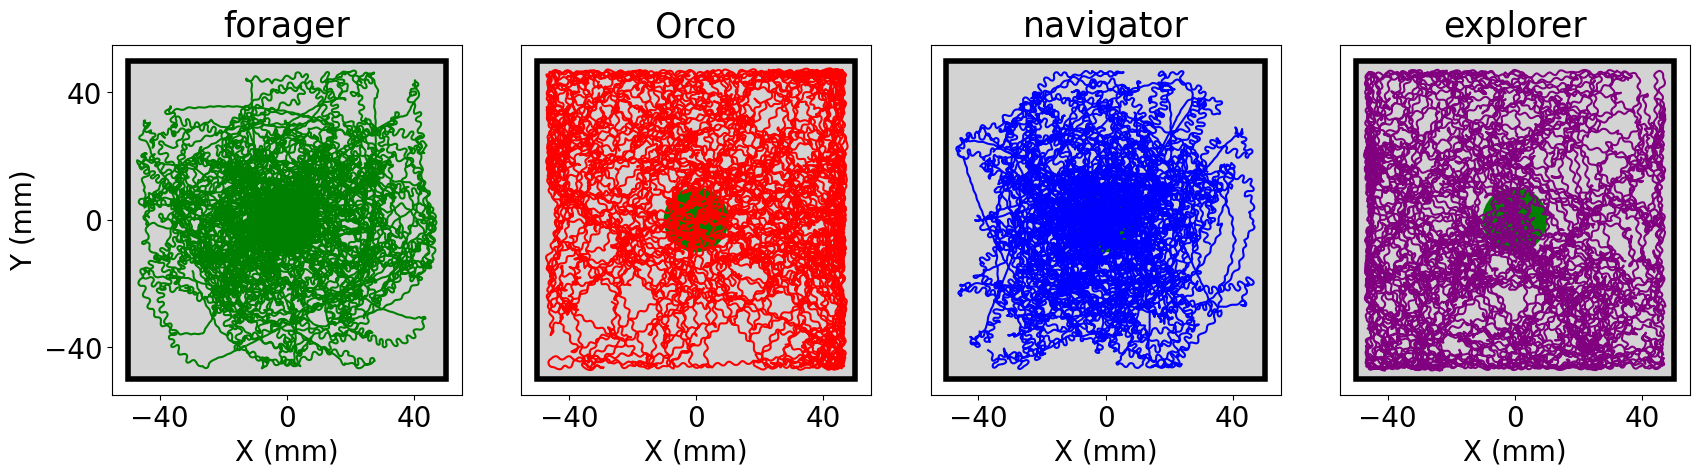

In [11]:
show("traj")

### Patch-related locomotion

The navigation index measures how directed the movement is, and the turn amplitudes say how sharply
the animals reorient. An animal that has found food and is exploiting it turns differently from one
still searching.

Y position


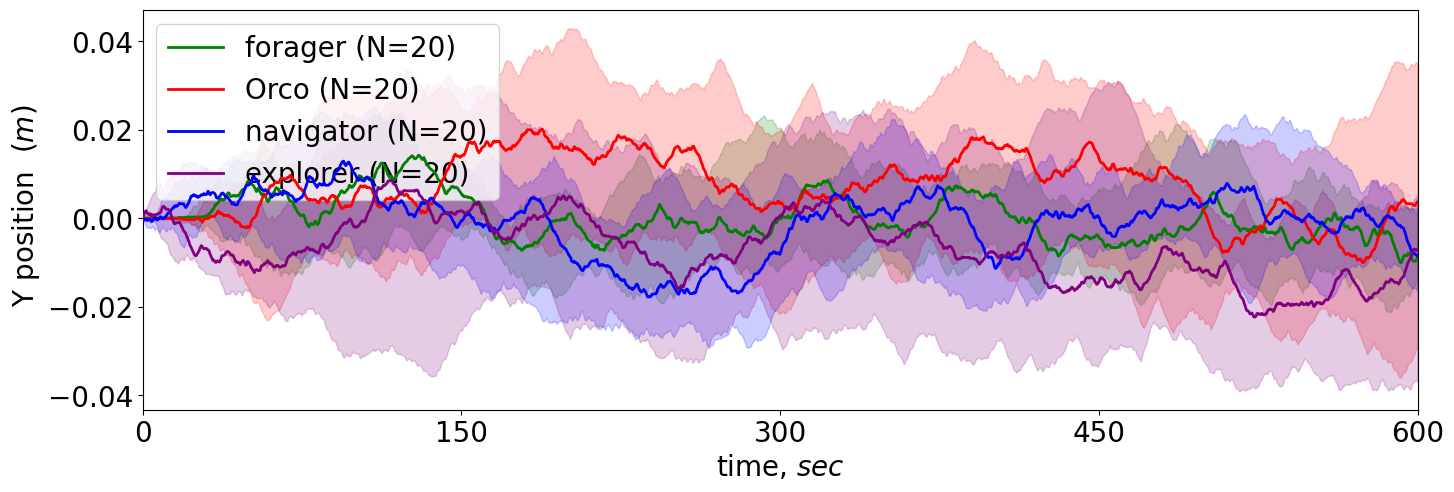

navigation index


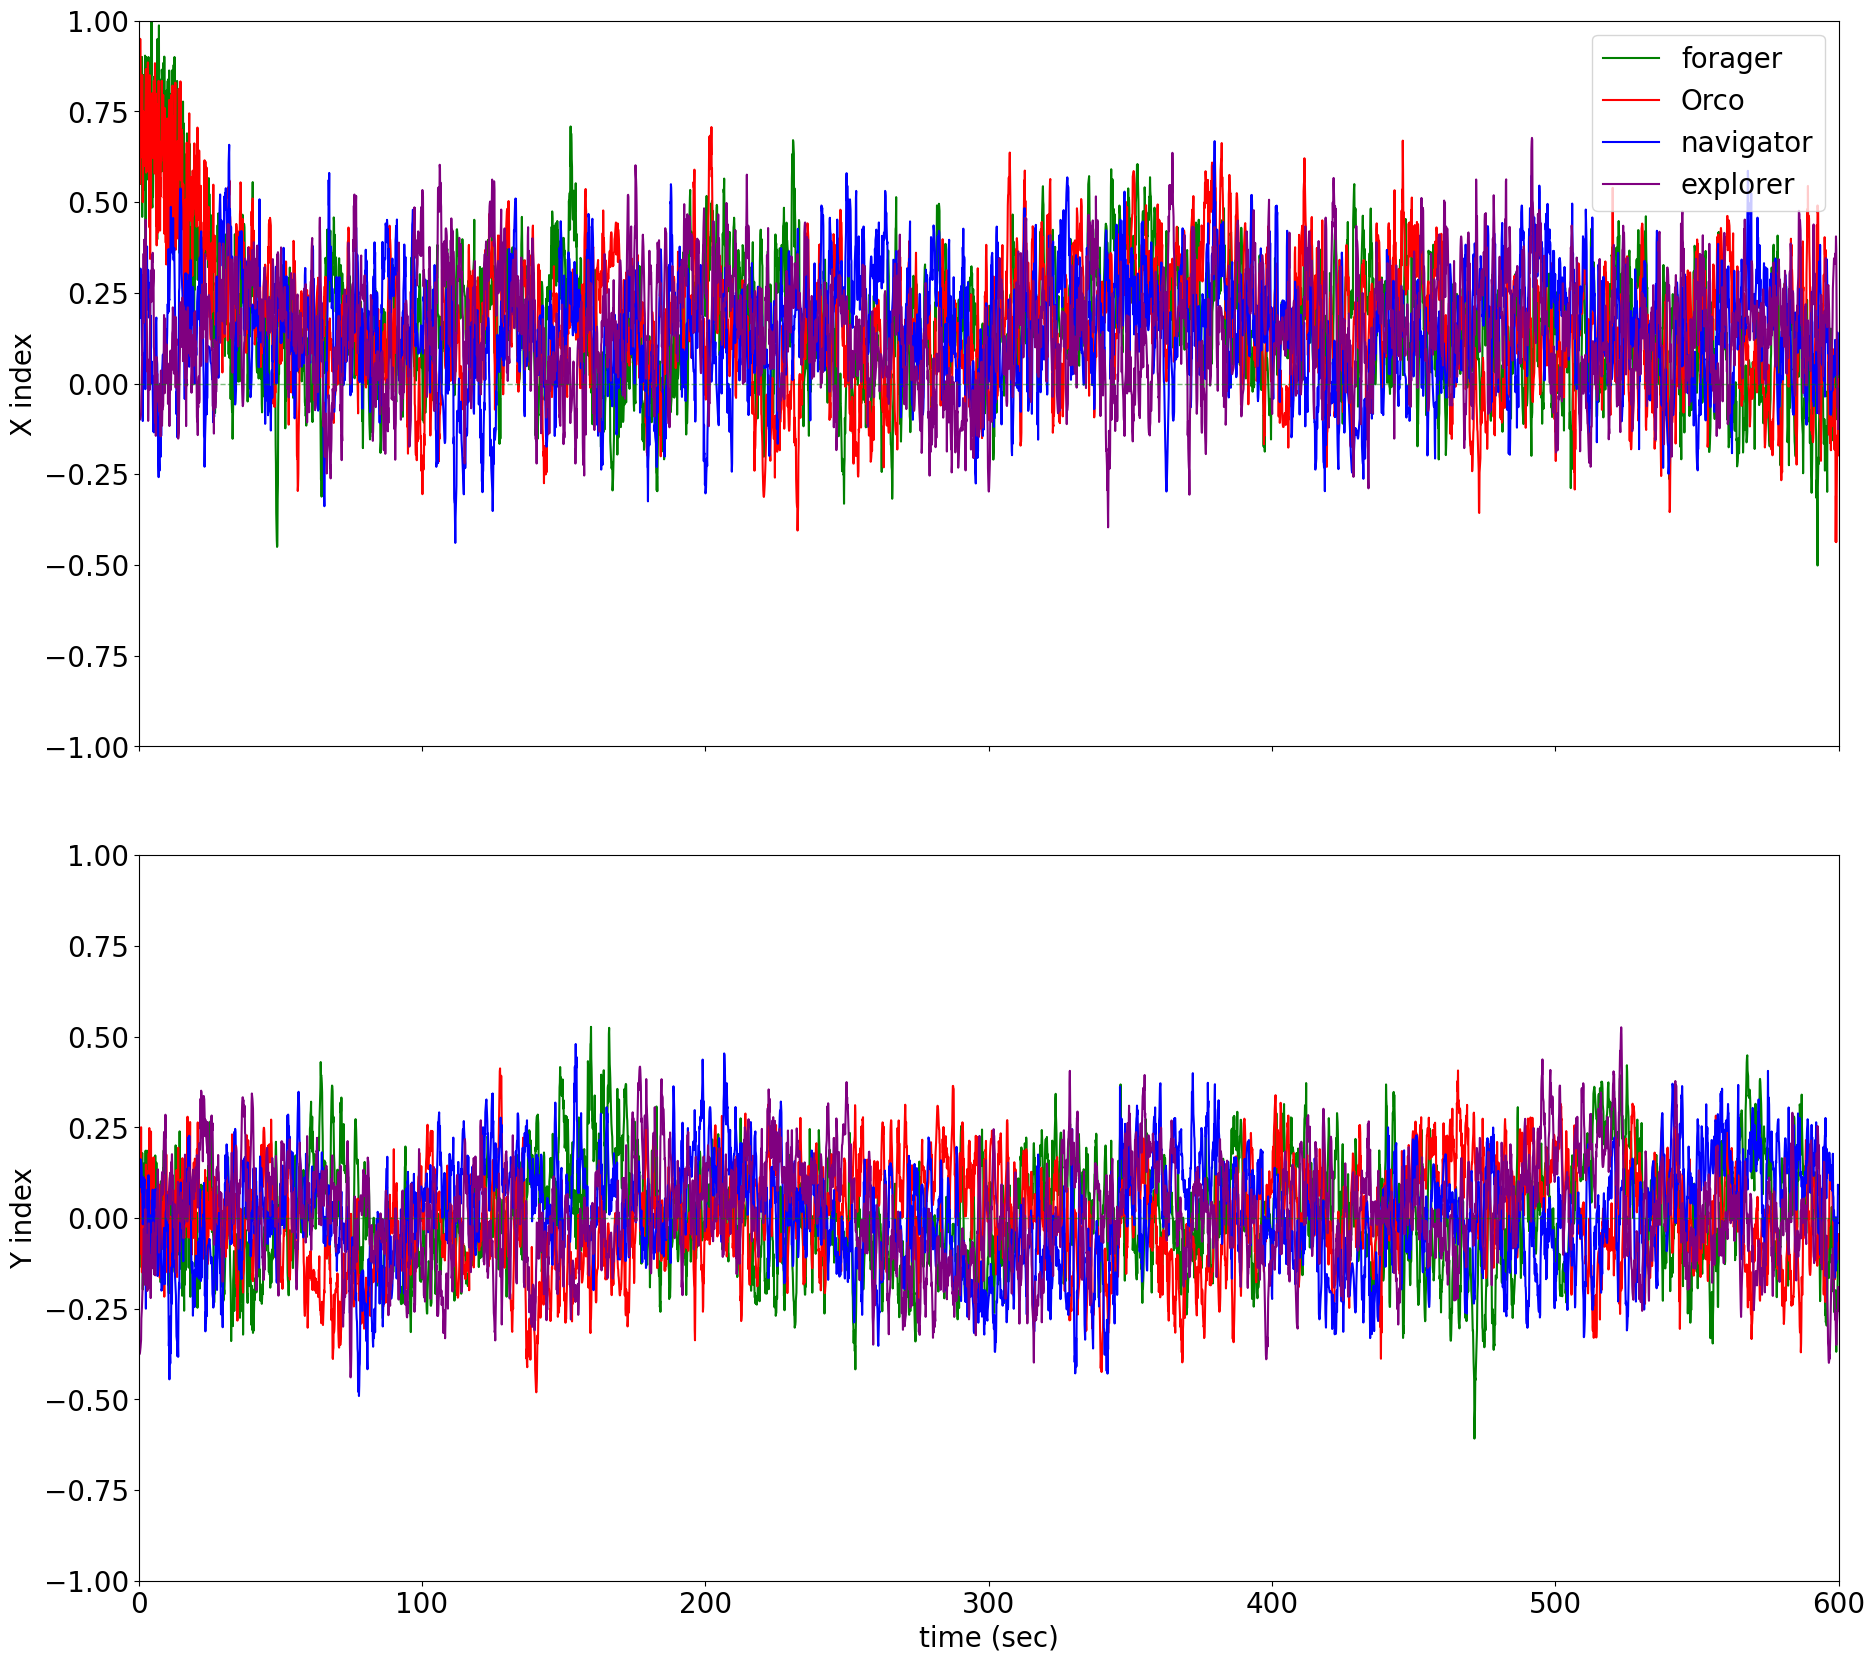

turn amplitude


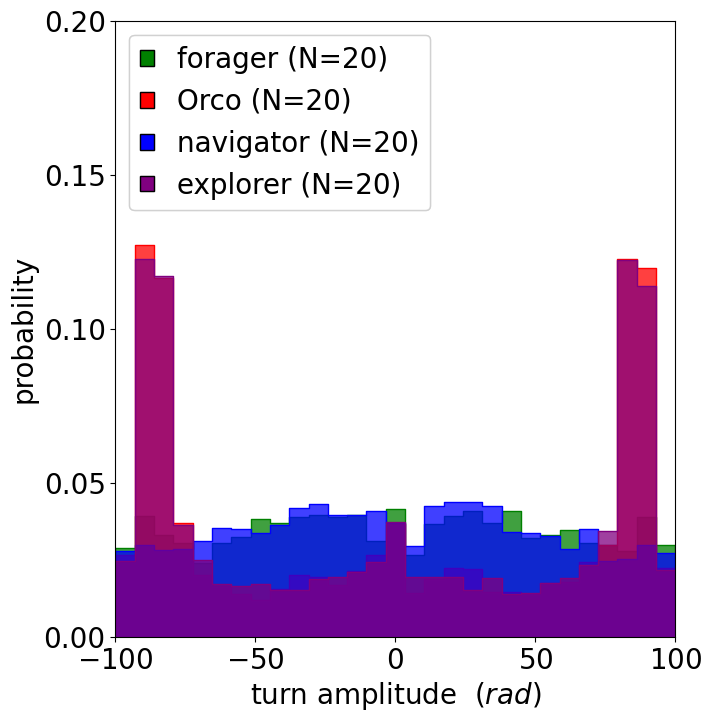

In [12]:
show("patch")

### Runs and pauses

The intermittency of each group. The feeding groups interrupt their crawling to eat, so their
epoch distributions are not the same as those of the two that only explore.

epochs


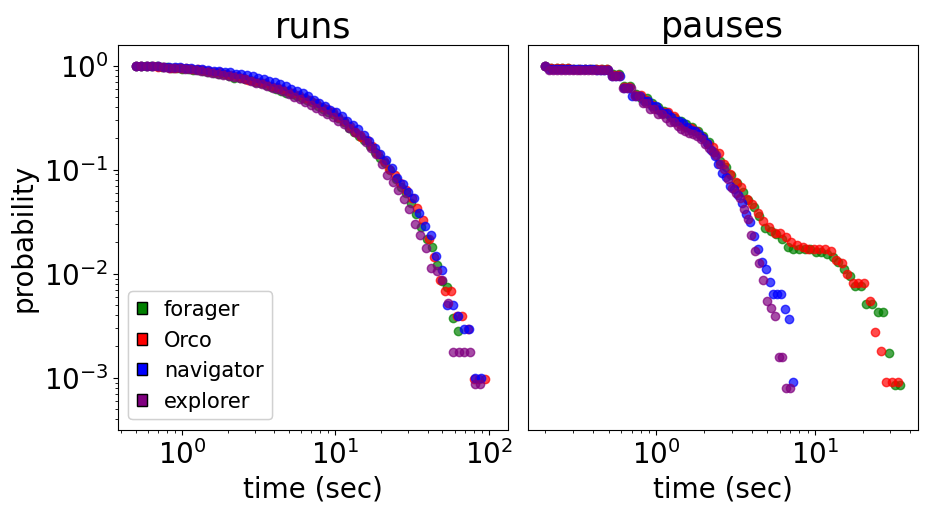

In [13]:
show("general")

### Locomotion relative to the patch

Because the experiment declares a source, the analysis measures every group against it : the bearing
to the patch, the distance to it, and that distance scaled by body length. This is the group-level
version of the curve drawn by hand above, produced by the platform instead. The group is named after
the source, so it is looked up by prefix rather than by a literal name.

bearing_to_Object


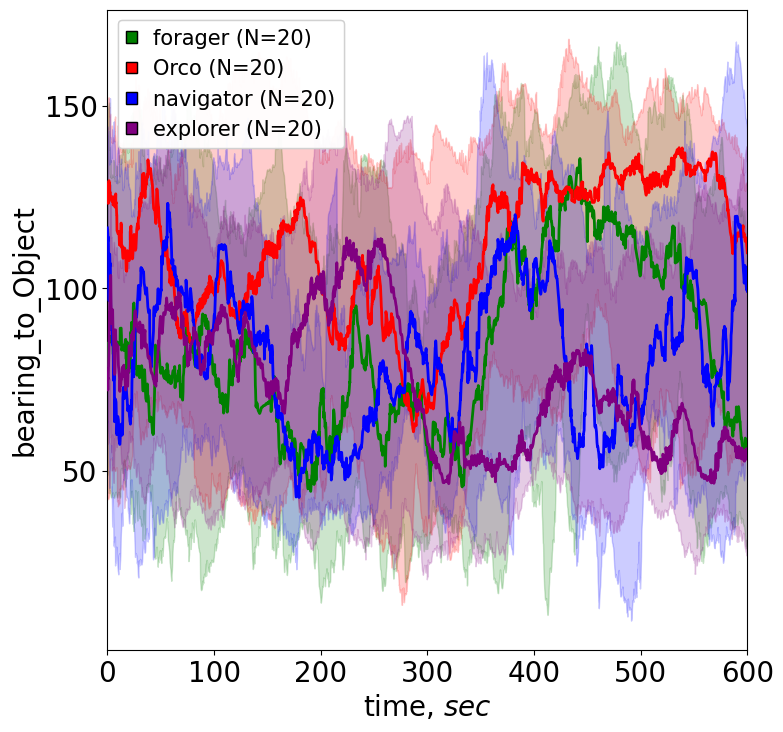

dst_to_Object


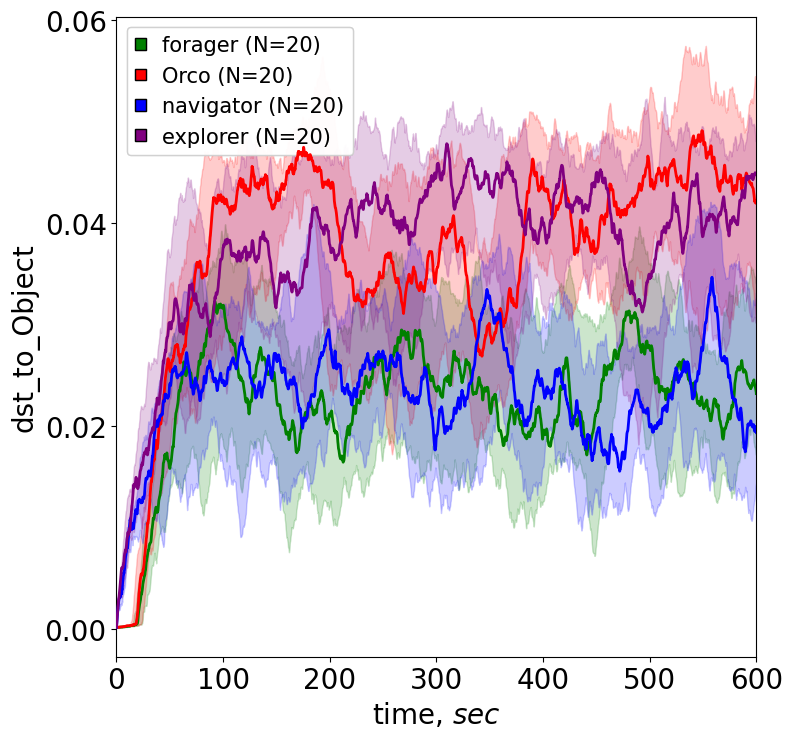

scaled_dst_to_Object


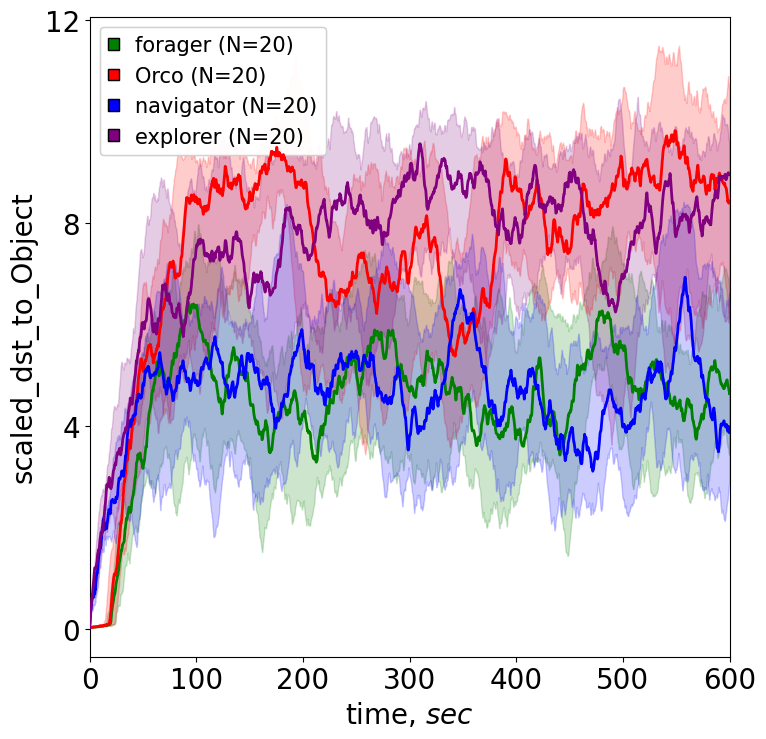

In [14]:
if RUN_SIMULATION:
    for gname in r.figs:
        if gname.startswith("locomotion_relative_to_source"):
            show(gname)

## Section 5 : What the comparison shows

Putting four models side by side isolates what each module contributes, which is the point of a
modular architecture : remove one piece and see what is lost. There are four single-step comparisons
in a 2x2, and each says something different.

- **`explorer` → `navigator`** adds an olfactor. The gain is purely spatial : the animal steers up
  the gradient and stays where the odor is instead of dispersing. It gains no food, having no feeder.
- **`explorer` → `Orco`** adds a feeder. The gain is consumption, taken wherever the animal happens
  to be, since nothing directs it to the patch or keeps it there.
- **`Orco` → `forager`** adds the olfactor on top of the feeder. This is the virtual counterpart of
  testing a wild-type animal beside an Orco mutant, with everything but the receptor held identical,
  and it roughly doubles the time spent on the patch.
- **`navigator` → `forager`** adds the feeder to an animal that already finds the patch. The two end
  up the same distance from it, but the forager spends more of its time actually on it, because
  feeding is what stops an animal that would otherwise crawl straight across.

Reading the last two together is what a 2x2 buys you over a pair of comparisons : neither module
explains the forager on its own. Olfaction supplies the position and feeding supplies the reason to
stay, and the intake at the end is the product of both.

**A closing caveat, and it is the one that matters most.** All of this is readable only because the
four models really are identical apart from the two modules under test and the EEB that necessarily
comes with a feeder. That was not true of the stored models until recently : every forager in the
registry carried an olfactor wired in `brute_force` mode - stopping the animal on a falling
concentration instead of steering it - inherited by accident from the model built just before it.
With that wiring the forager gained nothing measurable over the anosmic `Orco`, and the 2x2 above
would have read as a null result about olfaction rather than a fact about one configuration. A
comparison is worth exactly as much as the "everything else held equal" behind it, which is why the
capability table is printed from the models themselves rather than asserted in prose.

## Section 6 : Watching it happen

The same experiment, rendered. Each group keeps its own colour, so one clip shows the four
strategies side by side : the two olfactory groups holding the centre, and the two anosmic ones
dispersing away from it.

In [15]:
if SAVE_VIDEO:
    r_vid = ExpRun(
        experiment=EXPERIMENT,
        N=N,
        screen_kws={
            "vis_mode": "video",
            "show_display": False,
            "save_video": True,
            "media_dir": MEDIA_DIR,
            "video_file": "single_odor_patch_x4",
            "visible_trails": True,
        },
    )
    r_vid.simulate()
    print(f"Video written to {MEDIA_DIR}/single_odor_patch_x4.mp4")
else:
    print("Set SAVE_VIDEO = True to render this experiment to a video file.")

Set SAVE_VIDEO = True to render this experiment to a video file.


## What the paper reports

The behavioral architecture of Sakagiannis et al. (2025) is layered : a motor layer that crawls and
turns, a reactive layer that modulates it with sensory input, and an adaptive layer on top. The four
groups here are four different subsets of that architecture running in the same world - which is
what the paper means when it calls the framework modular.

The paper's own simulations cover exploration and chemotaxis, and its chemotaxis experiments
reconstruct Gomez-Marin et al. (2011). It reports no foraging comparison of this kind, so this
notebook is a demonstration of the architecture rather than a reproduction of a published figure.

The mechanism the paper validates is the one both olfactory groups use here : an olfactory signal
modulating the turner, reconstructed from Gomez-Marin et al. (2011). What this notebook adds is the
feeder underneath it, and the observation that the two modules contribute to a foraging result in
different currencies - one supplies the position, the other supplies the intake.

## Where to go next

- [Chemotaxis](chemotaxis.ipynb) - the olfactor on its own, in two odor landscapes.
- [Feeding on a food grid](feeding.ipynb) - the feeder on its own, with no patch to find.
- [Model evaluation](../5_optimization_and_evaluation/model_evaluation.ipynb) - comparing models
  against real data rather than against each other.
- Reference : [Brain module architecture](../../agents_environments/brain_module_architecture.md).

## References

> Sakagiannis PP, Jürgensen AM, Nawrot MP. 2025. *A behavioral architecture for realistic
simulations of Drosophila larva locomotion and foraging.* eLife 14:RP104262.
<https://doi.org/10.7554/eLife.104262>

> Gomez-Marin A, Stephens GJ, Louis M. 2011. *Active sampling and decision making in Drosophila
chemotaxis.* Nature Communications 2:410-441. <https://doi.org/10.1038/ncomms1455>

> Sakagiannis PP, Rapp H, Jovanic T, Nawrot MP. 2025. *Larvaworld: a behavioral simulation and
analysis platform for Drosophila larva.* bioRxiv.
<https://doi.org/10.1101/2025.06.15.659765>